<a href="https://colab.research.google.com/github/FarrelAD/Penglihatan-Komputer/blob/main/notebooks/week-5.ipynb" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Preparation

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob
from typing import Union, List

# 1st Practicum

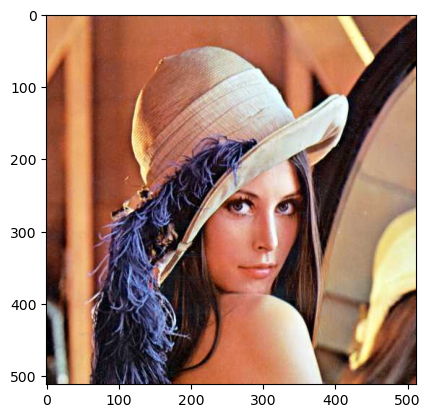

<BarContainer object of 256 artists>

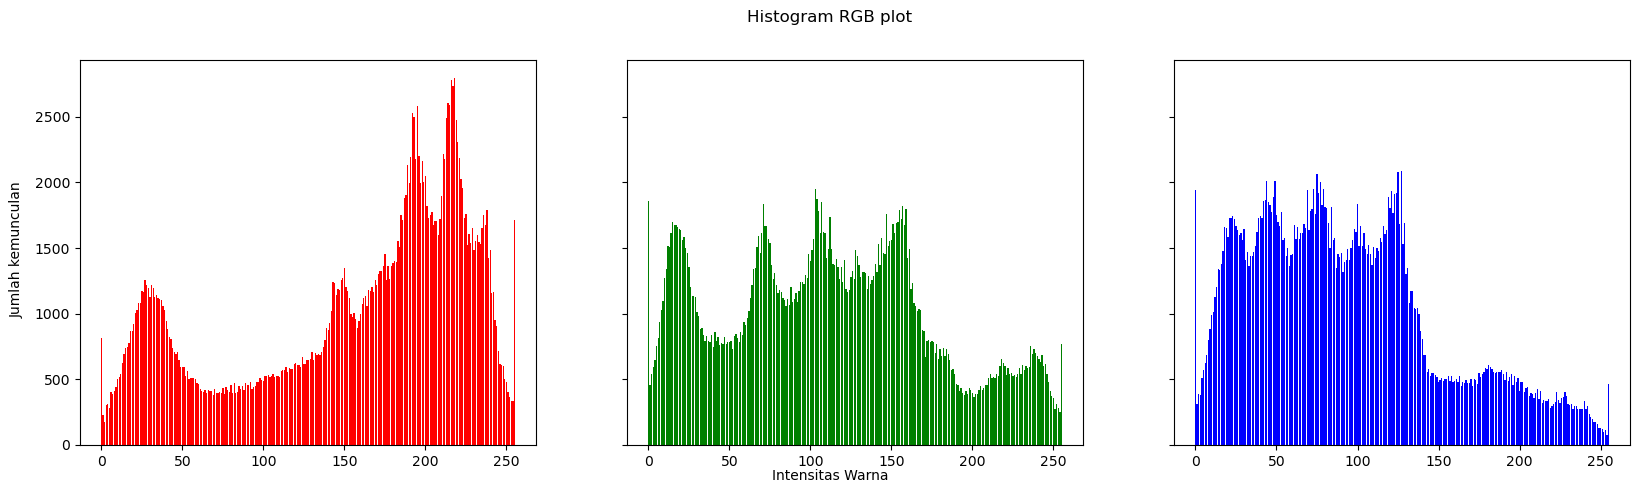

In [2]:
img = cv2.imread('../assets/lena.jpg')

if img is None:
    raise Exception('Image is not found!')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)


red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

plt.imshow(img)
plt.show()

fig, axes = plt.subplots(
    nrows=1, 
    ncols=3, 
    figsize=[20, 5], 
    sharex=True, 
    sharey=True
)
fig.suptitle('Histogram RGB plot')
fig.text(
    x=0.09, 
    y=0.5, 
    s='Jumlah kemunculan', 
    va='center', 
    rotation='vertical'
)
fig.text(
    x=0.5, 
    y=0.04, 
    s='Intensitas Warna', 
    ha='center'
)
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')

## 1. Create a histogram of the same image using the NumPy library, "histogram." Compare the results. Are the outputs the same?

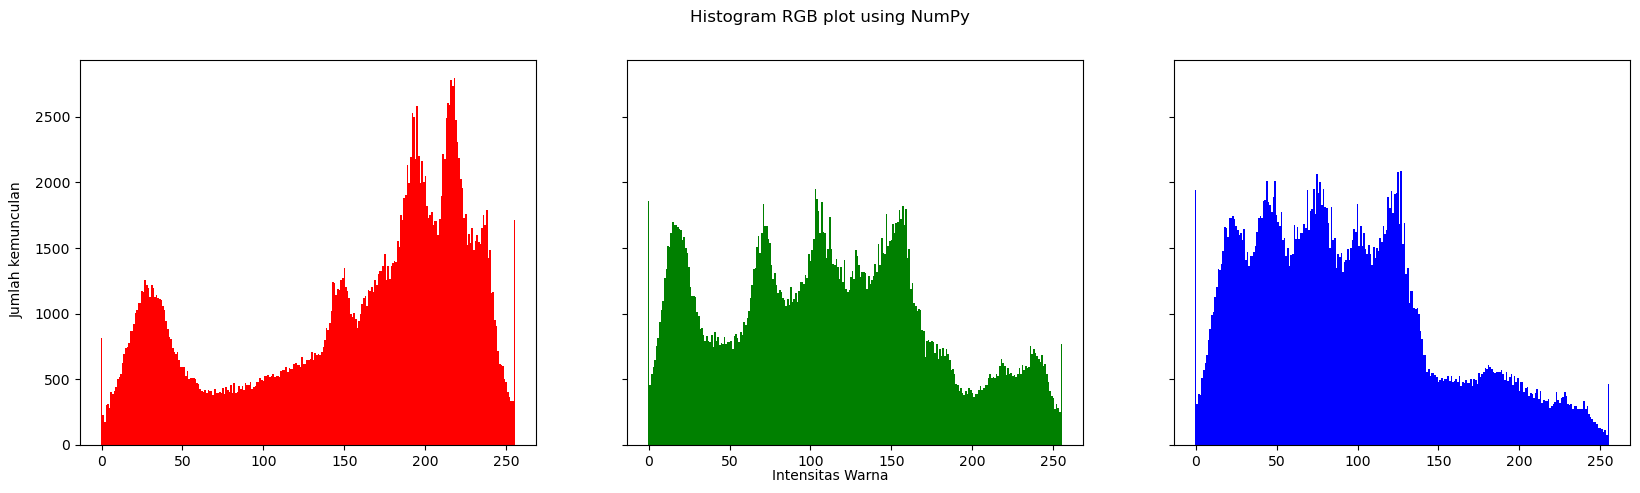

In [4]:
if img is None:
    raise Exception('Image is not found!')

red_channel = img[:, :, 0].flatten()
green_channel = img[:, :, 1].flatten()
blue_channel = img[:, :, 2].flatten()

red_hist, red_bins = np.histogram(
    red_channel, 
    bins=256, 
    range=(0, 256)
)
green_hist, green_bins = np.histogram(
    green_channel, 
    bins=256, 
    range=(0, 256)
)
blue_hist, blue_bins = np.histogram(
    blue_channel, 
    bins=256, 
    range=(0, 256)
)

# Plot the histograms
fig, axes = plt.subplots(
    nrows=1, 
    ncols=3, 
    figsize=[20, 5], 
    sharex=True, 
    sharey=True
)
fig.suptitle('Histogram RGB plot using NumPy')
fig.text(
    x=0.09, 
    y=0.5, 
    s='Jumlah kemunculan', 
    va='center', 
    rotation='vertical'
)
fig.text(
    x=0.5, 
    y=0.04, 
    s='Intensitas Warna', 
    ha='center'
)

# Use the bin centers for plotting
axes[0].bar(red_bins[:-1], red_hist, color='red', width=1)
axes[1].bar(green_bins[:-1], green_hist, color='green', width=1)
axes[2].bar(blue_bins[:-1], blue_hist, color='blue', width=1)

plt.show()

The histogram looks different. Histogram created by NumPy histogram looks more dense. It doesn't have any gaps between each bin

## 2. Create a histogram using the image KTM lama.jpg. Analyze the intensity distribution of the resulting histogram to see if the image tends to be dark, light, or low-contrast.

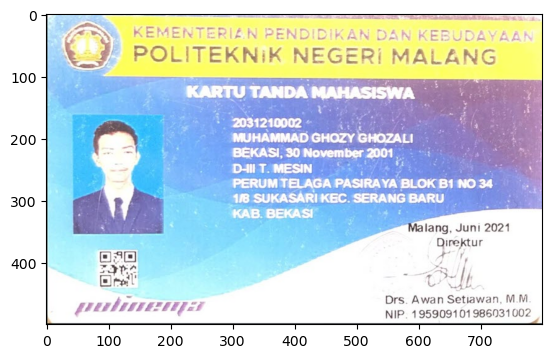

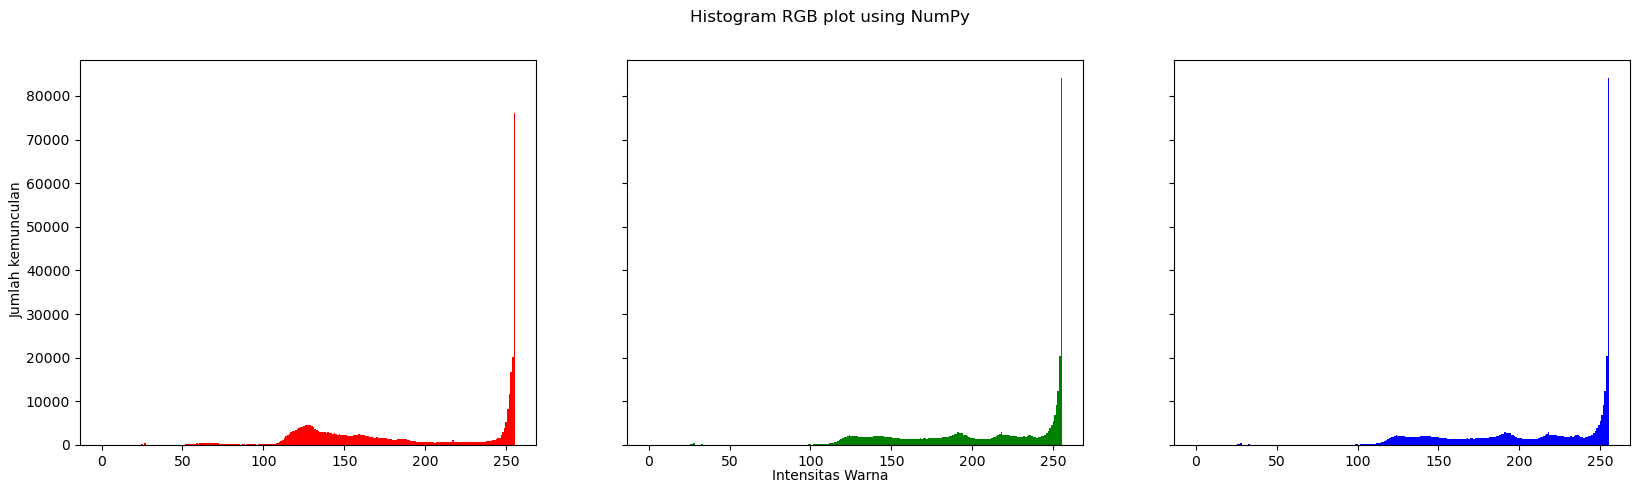

In [5]:
img_ktm = cv2.imread('../assets/ktm-lama.jpg')

if img_ktm is None:
    raise Exception('Image is not found!')

img_ktm_rgb = cv2.cvtColor(img_ktm, cv2.COLOR_BGR2RGB)

red_channel = img_ktm[:, :, 2].flatten()
green_channel = img_ktm[:, :, 1].flatten()
blue_channel = img_ktm[:, :, 1].flatten()

red_hist, red_bins = np.histogram(
    red_channel, 
    bins=256, range=(0, 256)
)
green_hist, green_bins = np.histogram(
    green_channel, 
    bins=256, 
    range=(0, 256)
)
blue_hist, blue_bins = np.histogram(
    blue_channel, 
    bins=256, 
    range=(0, 256)
)

plt.imshow(img_ktm_rgb)
plt.show()

# Plot the histograms
fig, axes = plt.subplots(
    nrows=1, 
    ncols=3, 
    figsize=[20, 5], 
    sharex=True, 
    sharey=True
)
fig.suptitle('Histogram RGB plot using NumPy')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

# Use the bin centers for plotting
axes[0].bar(red_bins[:-1], red_hist, color='red', width=1)
axes[1].bar(green_bins[:-1], green_hist, color='green', width=1)
axes[2].bar(blue_bins[:-1], blue_hist, color='blue', width=1)

plt.show()

The image form `ktm-lama.jpg` actually seems to have characteristic with high brightness. The intensity is very high. It's easily see by the actual image or by seeing the histogram itself. The histogram tend to very skewed to right side.

# 2nd Practicum - Histogram Equalization

In [6]:
def plot_rgb_histograms(
    images: Union[np.ndarray, List[np.ndarray]], 
    titles=None
) -> None:
    """
    Plot RGB histograms for 1 or 2 images.
    
    Args:
        images: single image (numpy array) or list of 2 images (loaded by cv2.imread)
        titles: list of titles corresponding to images (optional)
    """
    # Ensure images is a list
    if not isinstance(images, list):
        images = [images]
    n = len(images)
    if n not in [1, 2]:
        raise ValueError("Only 1 or 2 images are supported.")

    # Set default titles if not provided
    if titles is None:
        titles = [f"Image {i+1}" for i in range(n)]

    # Collect histograms
    histograms = []
    for img in images:
        if img is None:
            raise ValueError("One of the images is None. Check the file path.")
        b, g, r = cv2.split(img)
        red_hist, _ = np.histogram(r.flatten(), bins=256, range=(0, 256))
        green_hist, _ = np.histogram(g.flatten(), bins=256, range=(0, 256))
        blue_hist, _ = np.histogram(b.flatten(), bins=256, range=(0, 256))
        histograms.append((red_hist, green_hist, blue_hist))

    # --- Plot individual channel histograms for each image ---
    for idx in range(n):
        r_hist, g_hist, b_hist = histograms[idx]
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'RGB Channel Histograms - {titles[idx]}', fontsize=16)

        axes[0].bar(range(256), r_hist, color='red', alpha=0.7, width=1)
        axes[0].set_title('Red Channel')
        axes[0].set_xlabel('Intensity')
        axes[0].set_ylabel('Frequency')

        axes[1].bar(range(256), g_hist, color='green', alpha=0.7, width=1)
        axes[1].set_title('Green Channel')
        axes[1].set_xlabel('Intensity')
        axes[1].set_ylabel('Frequency')

        axes[2].bar(range(256), b_hist, color='blue', alpha=0.7, width=1)
        axes[2].set_title('Blue Channel')
        axes[2].set_xlabel('Intensity')
        axes[2].set_ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    # --- Plot combined RGB histograms side by side ---
    fig, axes = plt.subplots(1, n, figsize=(8*n, 5))
    if n == 1:
        axes = [axes]  # make iterable
    for idx in range(n):
        r_hist, g_hist, b_hist = histograms[idx]
        axes[idx].plot(range(256), r_hist, color='red', alpha=0.7, label='Red')
        axes[idx].plot(range(256), g_hist, color='green', alpha=0.7, label='Green')
        axes[idx].plot(range(256), b_hist, color='blue', alpha=0.7, label='Blue')
        axes[idx].set_title(f'Combined RGB Histogram - {titles[idx]}')
        axes[idx].set_xlabel('Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
    plt.tight_layout()
    plt.show()

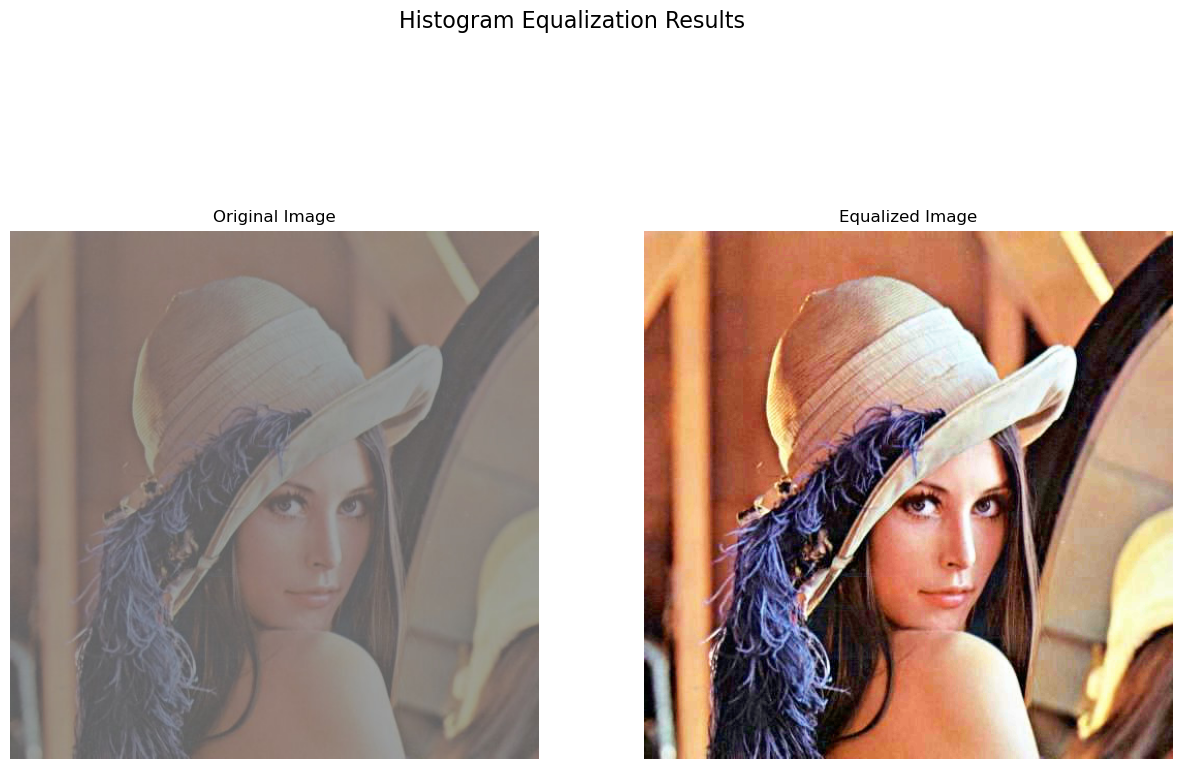

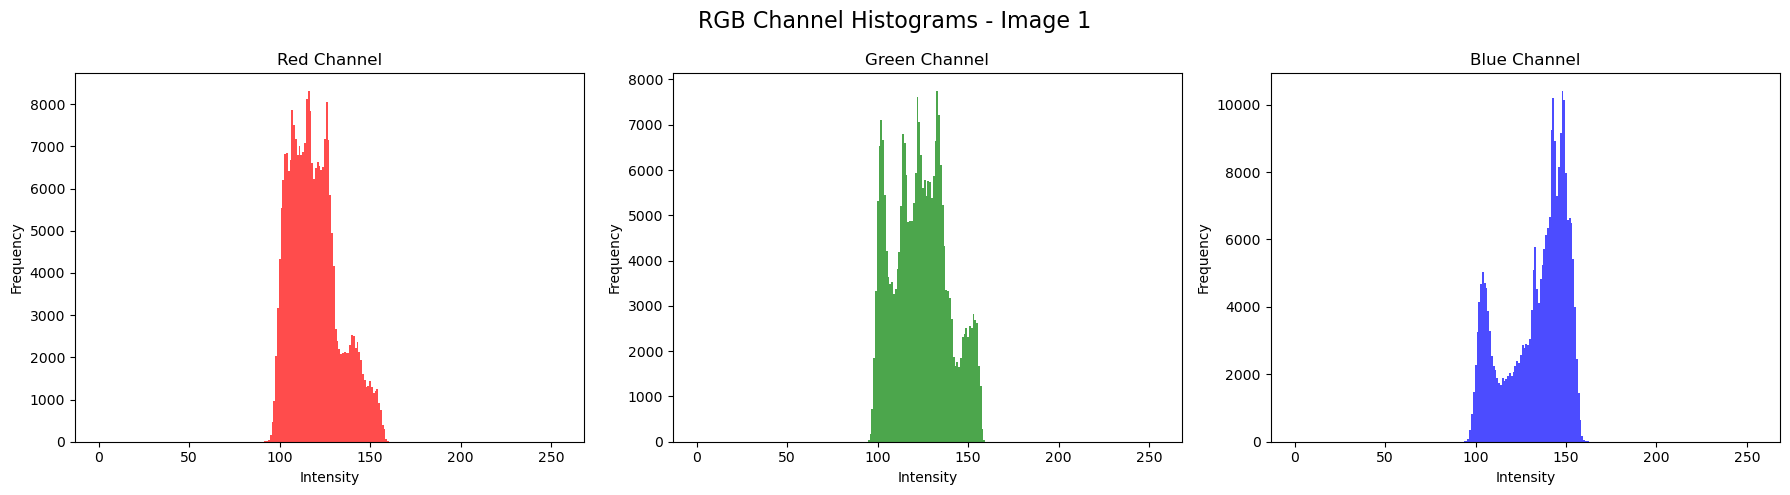

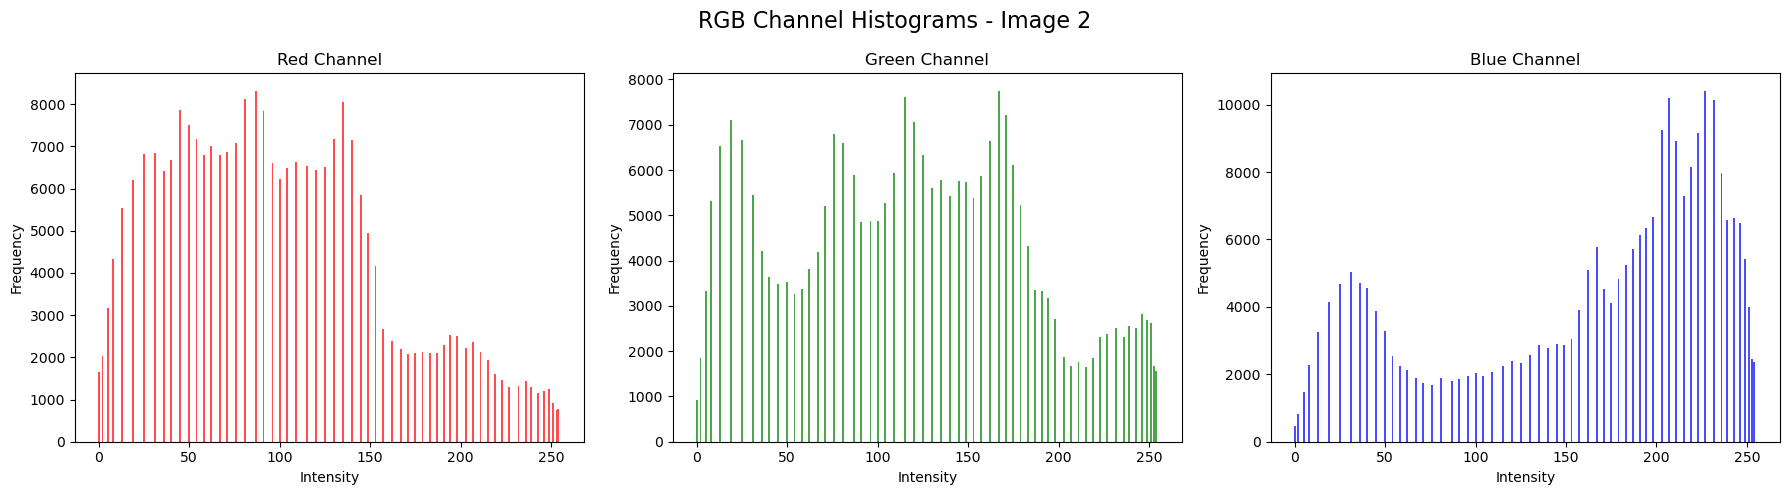

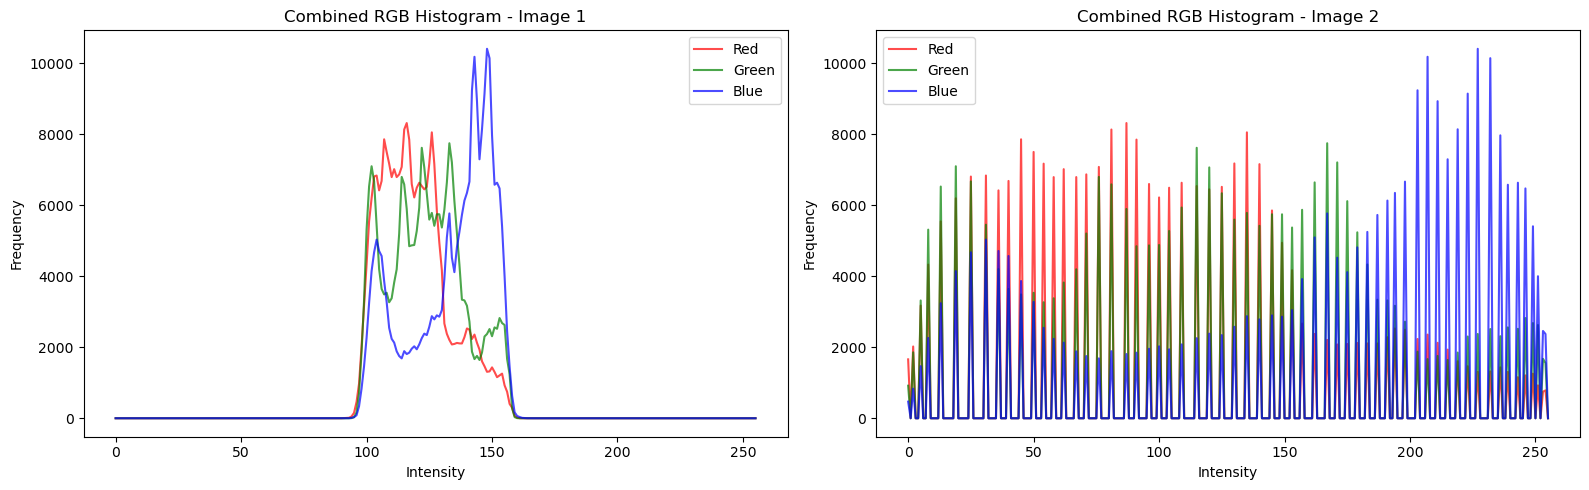

In [ ]:
img_lena_lc = cv2.imread('../assets/lena-lc.jpg')

if img_lena_lc is None:
    raise Exception('Image is not found!')


def histogram_equalization(
    img: np.ndarray
):
    hist, bins = np.histogram(img.flatten(), bins=256, range=(0, 256))
    
    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()
    
    # Normalize CDF
    cdf_normalized = cdf * 255 / cdf[-1]
    
    equalized_img = np.interp(img.flatten(), bins[:-1], cdf_normalized).reshape(img.shape).astype(np.uint8)
    
    # Calculate histogram of equalized image
    equalized_hist, _ = np.histogram(equalized_img.flatten(), bins=256, range=(0, 256))
    
    return equalized_img, hist, equalized_hist

# Apply histogram equalization
equalized_img, original_hist, equalized_hist = histogram_equalization(img_lena_lc)



img_lena_lc_rgb = cv2.cvtColor(img_lena_lc, cv2.COLOR_BGR2RGB)
img_lena_equalized_rgb = cv2.cvtColor(equalized_img, cv2.COLOR_BGR2RGB)


# Display results
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(15, 10)
)
fig.suptitle('Histogram Equalization Results', fontsize=16)

# Original image
axes[0].imshow(img_lena_lc_rgb, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Equalized image
axes[1].imshow(img_lena_equalized_rgb, cmap='gray')
axes[1].set_title('Equalized Image')
axes[1].axis('off')

# Display histogram
plot_rgb_histograms([img_lena_lc_rgb, img_lena_equalized_rgb])

Show histogram by using OpenCV library

In [8]:
# create a helper function for calculating equalize histogram
def apply_equalized_hist_numpy(
    img: np.ndarray
) -> np.ndarray:
    blue, green, red = cv2.split(img)
    
    b_equalized = cv2.equalizeHist(blue)
    g_equalized = cv2.equalizeHist(green)
    r_equalized = cv2.equalizeHist(red)

    return cv2.merge((
        b_equalized, 
        g_equalized, 
        r_equalized
    ))

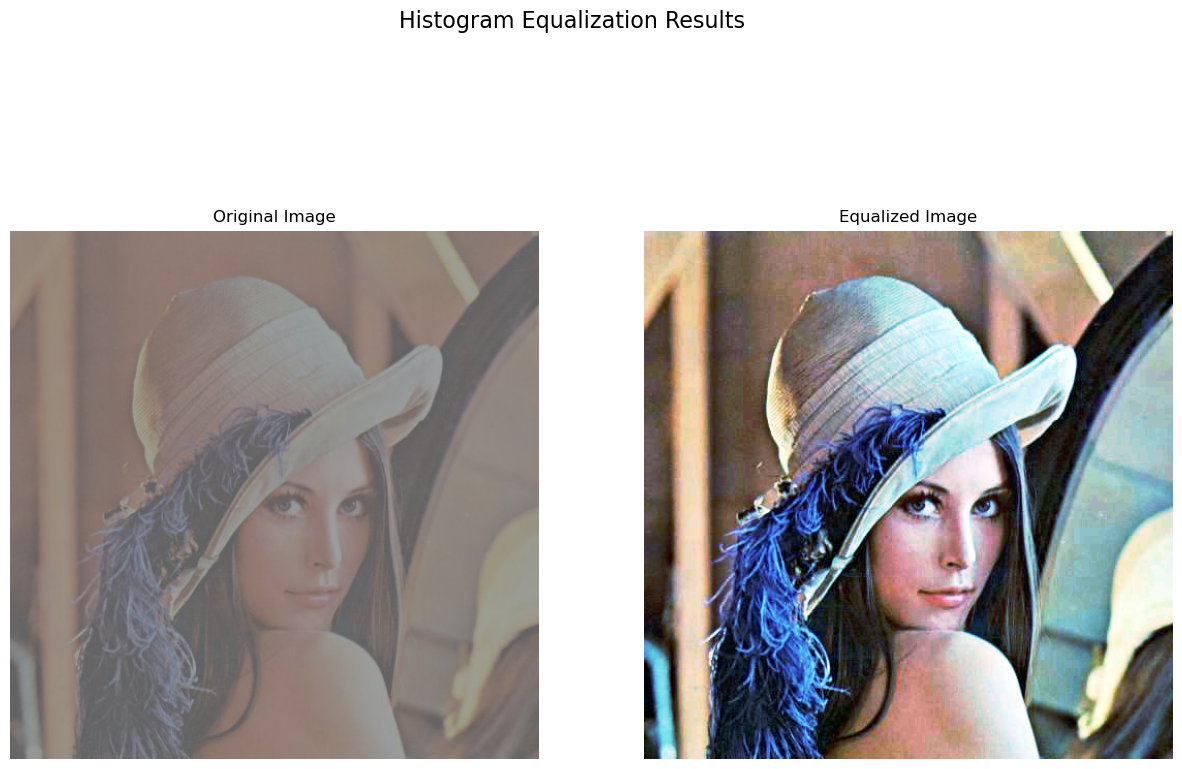

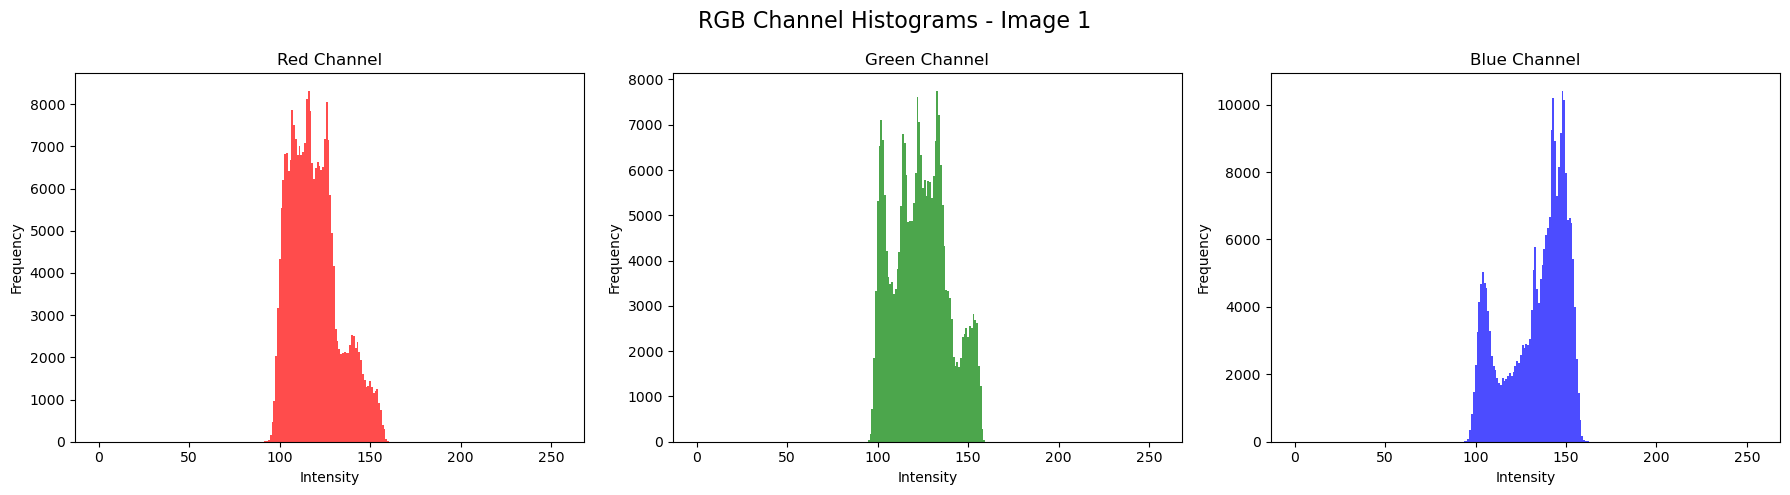

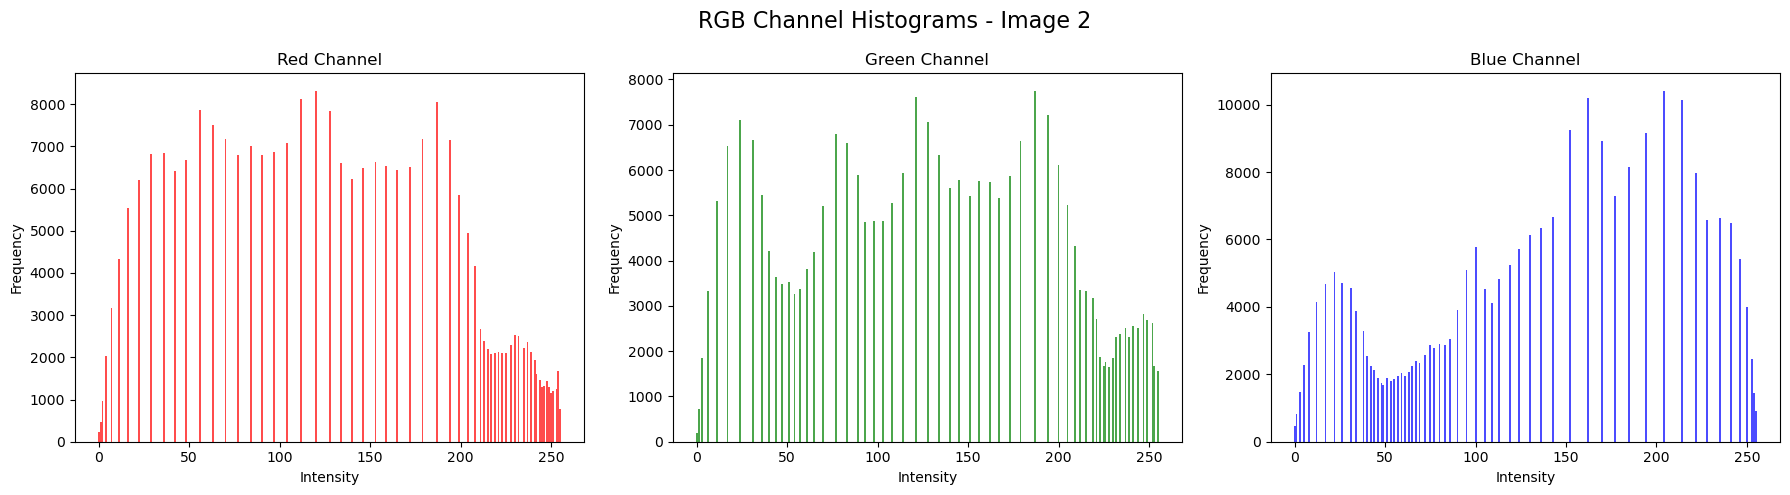

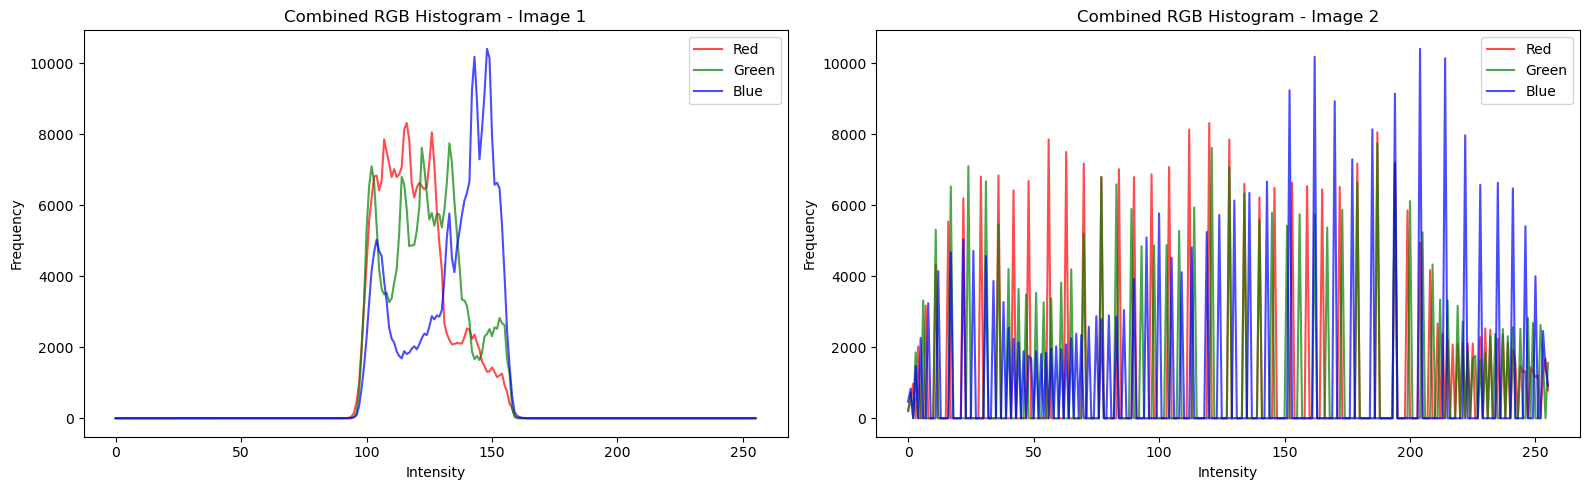

In [ ]:
img_lena_lc = cv2.imread('../assets/lena-lc.jpg')

if img_lena_lc is None:
    raise Exception('Image is not found!')

equalized_bgr = apply_equalized_hist_numpy(img_lena_lc)


# Show results
img_lena_lc_rgb = cv2.cvtColor(img_lena_lc, cv2.COLOR_BGR2RGB)
img_lena_equalized_rgb = cv2.cvtColor(equalized_bgr, cv2.COLOR_BGR2RGB)


# Display results
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(15, 10)
)
fig.suptitle('Histogram Equalization Results', fontsize=16)

# Original image
axes[0].imshow(img_lena_lc_rgb, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Equalized image
axes[1].imshow(img_lena_equalized_rgb, cmap='gray')
axes[1].set_title('Equalized Image')
axes[1].axis('off')

# Display histogram
plot_rgb_histograms([img_lena_lc_rgb, img_lena_equalized_rgb])

## 1. Lena Image Comparison

a. Apply *histogram equalization* to the image `lena.jpg`.

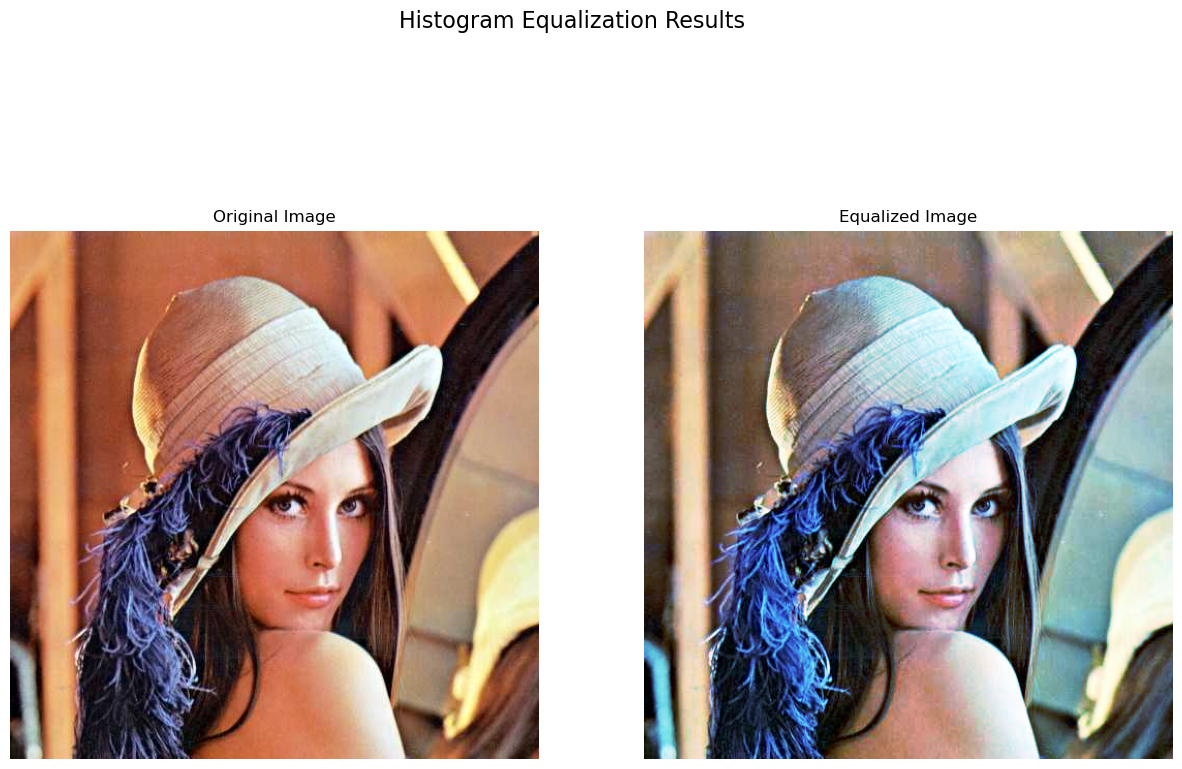

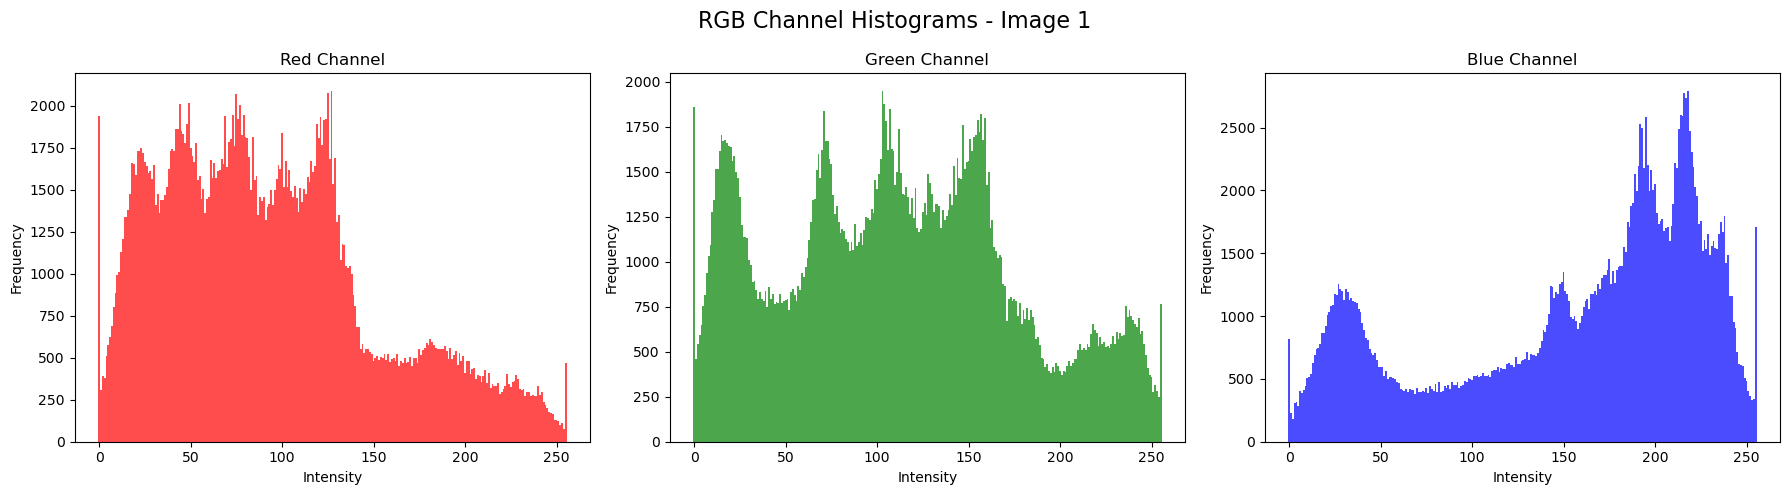

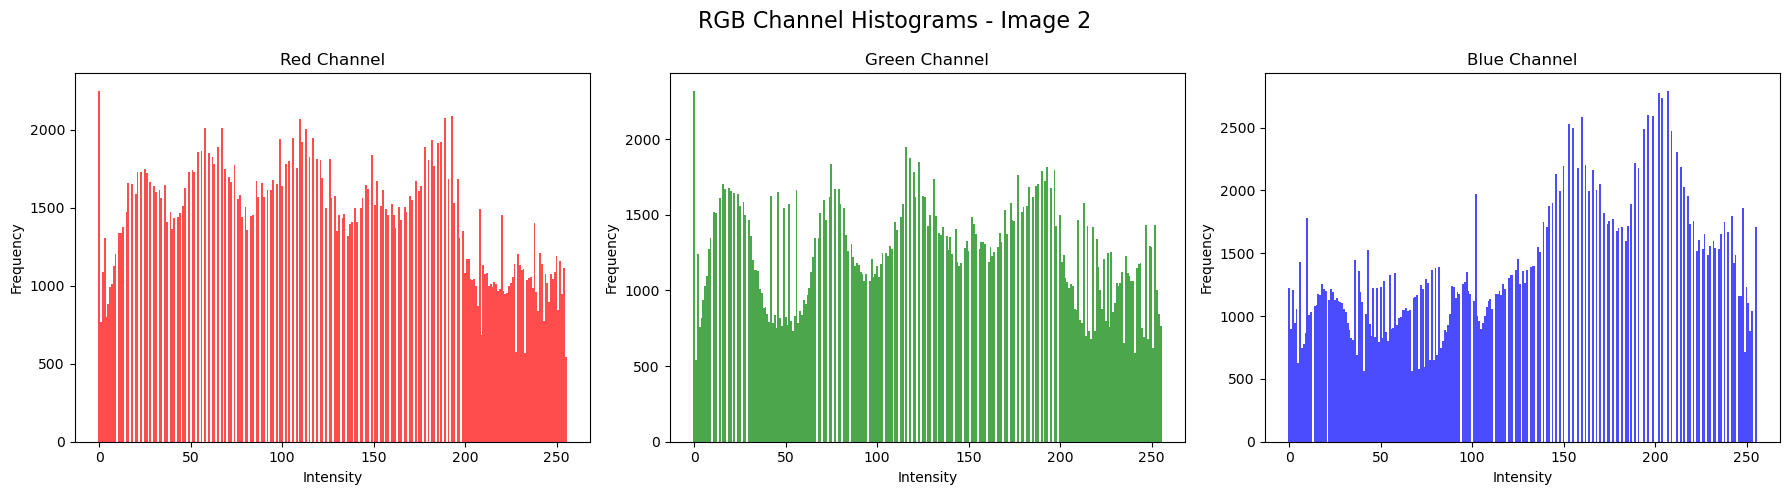

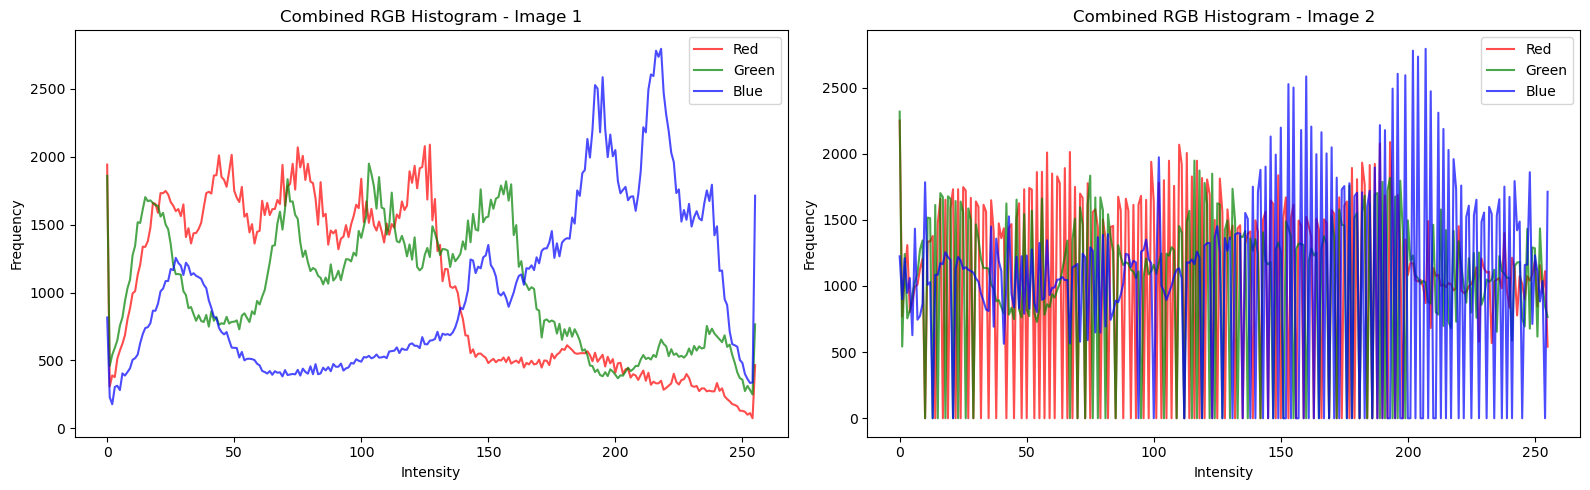

In [10]:
img_lena = cv2.imread('../assets/lena.jpg')

if img_lena is None:
    raise Exception('Image is not found!')

img_lena_equalized = apply_equalized_hist_numpy(img_lena)

# Show results
img_lena_lc_rgb = cv2.cvtColor(img_lena, cv2.COLOR_BGR2RGB)
img_lena_equalized_rgb = cv2.cvtColor(img_lena_equalized, cv2.COLOR_BGR2RGB)


# Display results
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))
fig.suptitle('Histogram Equalization Results', fontsize=16)

# Original image
axes[0].imshow(img_lena_lc_rgb, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Equalized image
axes[1].imshow(img_lena_equalized_rgb, cmap='gray')
axes[1].set_title('Equalized Image')
axes[1].axis('off')

# Display histogram
plot_rgb_histograms([img_lena_lc_rgb, img_lena_equalized_rgb])

b. Calculate the **PSNR** value between the original image and the equalized image.

In [11]:
psnr_value = cv2.PSNR(
    src1=img_lena, # type: ignore
    src2=img_lena_equalized
) 

print(f"The value of PSNR is {psnr_value}")

The value of PSNR is 17.948401486845306


c. Is the PSNR value high or low? What does this value mean for the image? Are there any new details revealed after equalization?

In [12]:
if psnr_value > 40:
    quality = "Excellent - almost identical to the original"
elif psnr_value > 30:
    quality = "Good - slight difference from the original"
elif psnr_value > 20:
    quality = "Moderate - noticeable differences"
else:
    quality = "Poor - image looks quite different from the original"

print(f"Image quality interpretation: {quality}")

Image quality interpretation: Poor - image looks quite different from the original


The new image looks cooler, so it has colors that are more dominant in blue.

## 2. Using the Image **KTM-lama.jpg**

a. Apply *histogram equalization* to the image *ktm-lama.jpg*.  

In [13]:
img_ktm = cv2.imread('../assets/ktm-lama.jpg')

if img_ktm is None:
    raise Exception('Image is not found!')

img_equalized = apply_equalized_hist_numpy(img_ktm)

print('ktm-lama.jpg finish to equalized!')

ktm-lama.jpg finish to equalized!


b. Display the original image, the equalized image, and the histograms of both images in a single layout.  

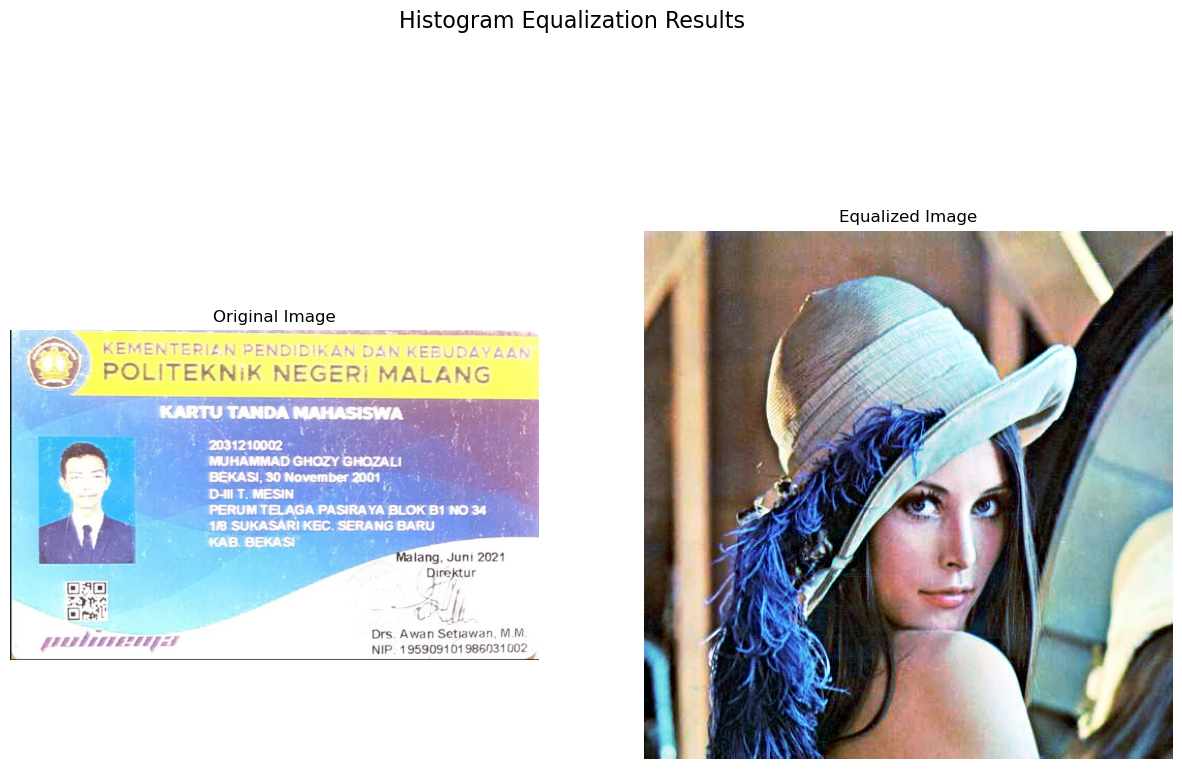

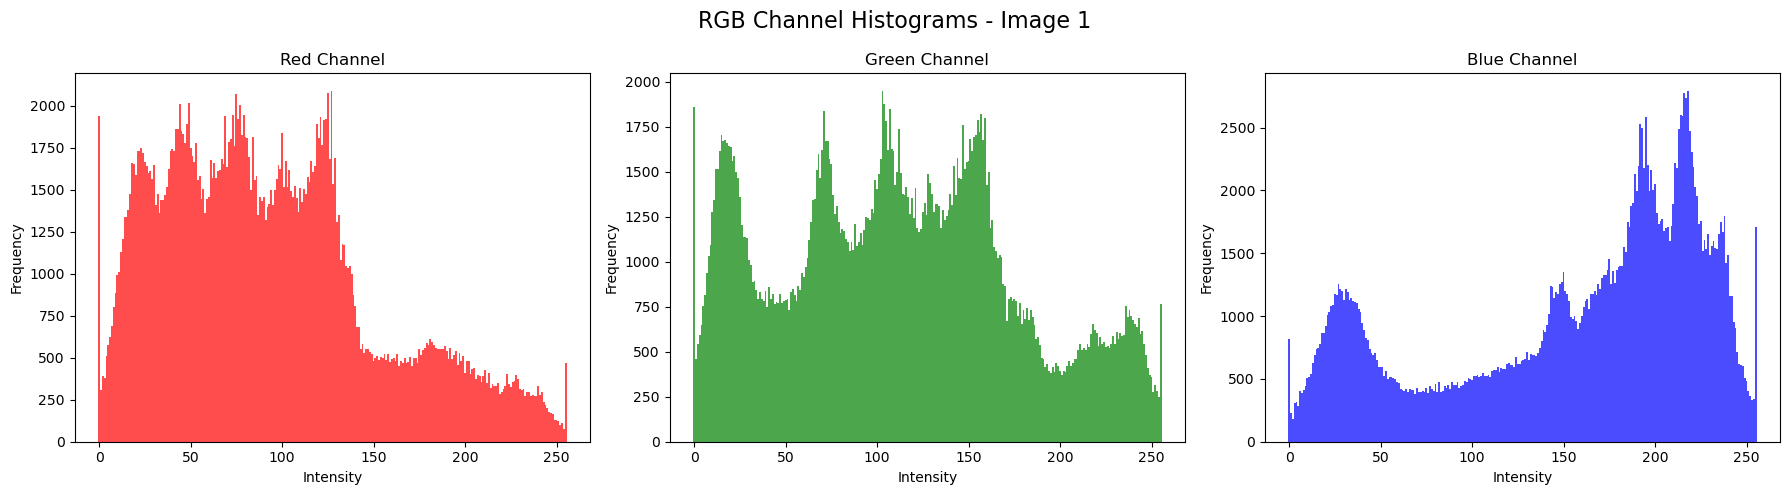

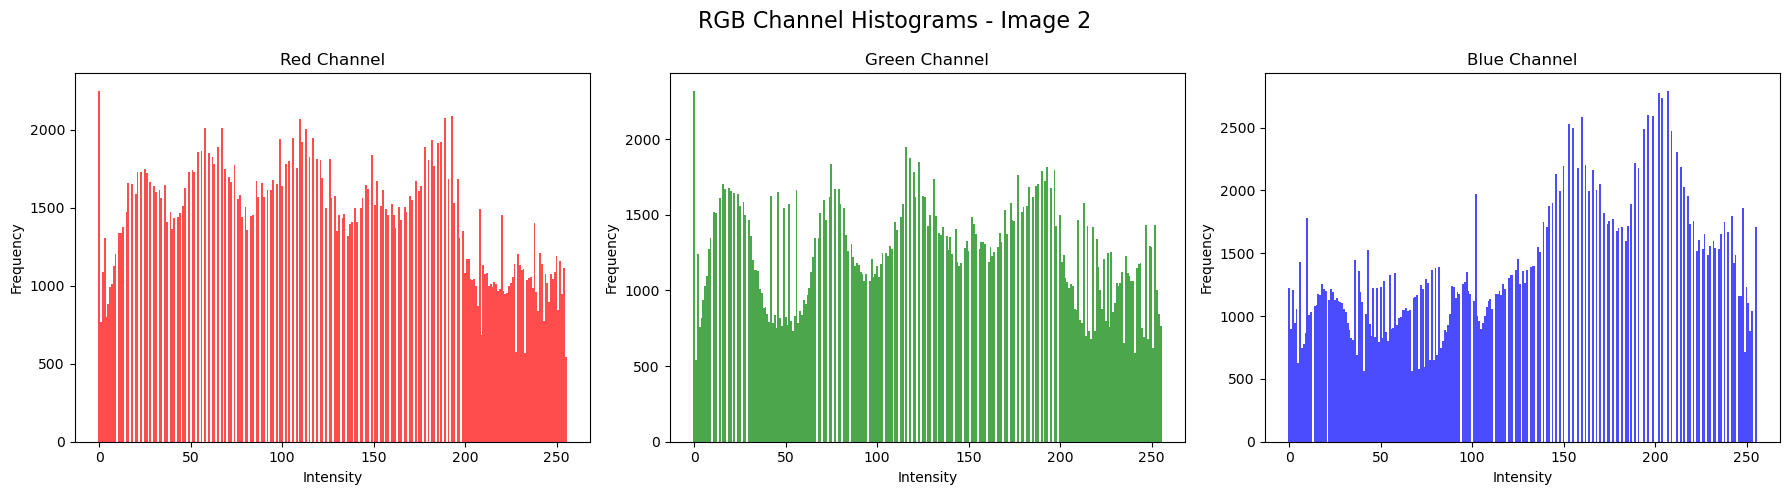

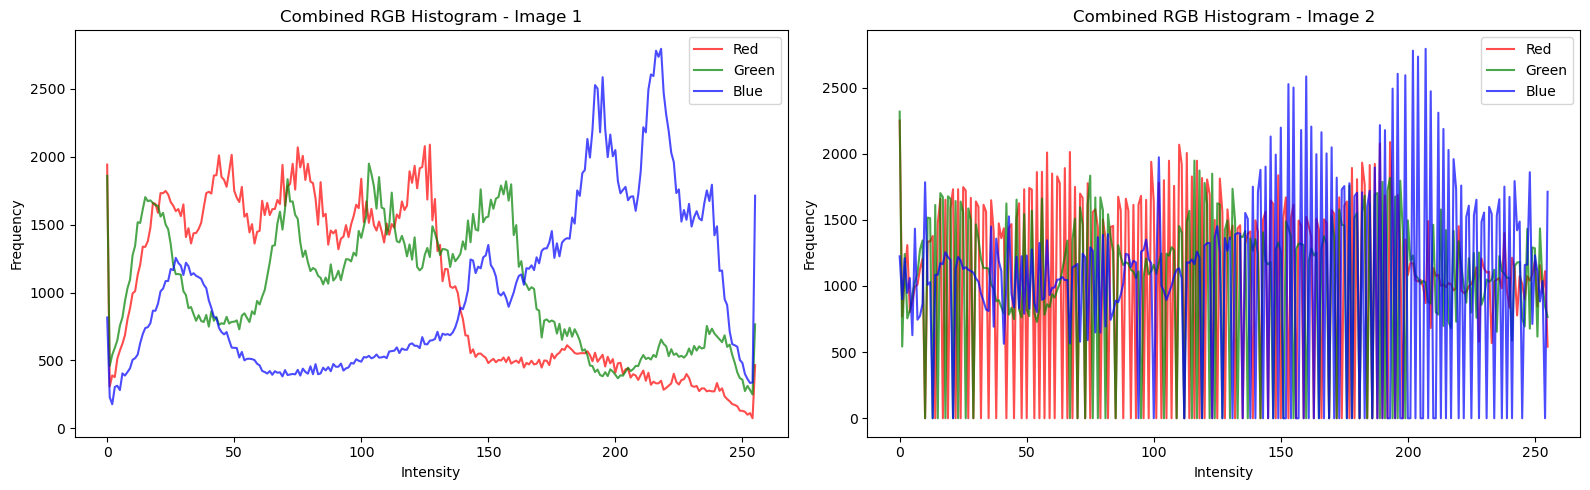

In [14]:
# Show results
img_ktm_rgb = cv2.cvtColor(img_ktm, cv2.COLOR_BGR2RGB) # type: ignore
img_equalized_rgb = cv2.cvtColor(
    img_lena_equalized, 
    cv2.COLOR_BGR2RGB
)


# Display results
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))
fig.suptitle('Histogram Equalization Results', fontsize=16)

# Original image
axes[0].imshow(img_ktm_rgb, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Equalized image
axes[1].imshow(img_equalized_rgb, cmap='gray')
axes[1].set_title('Equalized Image')
axes[1].axis('off')

# Display histogram
plot_rgb_histograms([img_lena_lc_rgb, img_lena_equalized_rgb])

c. Compare *ktm-lama.jpg* before and after *histogram equalization*. Explain the differences that can be observed (e.g., in the face, text, or background). Do these changes improve the quality of information in the image, or do they make it harder to interpret?

Now the image brightness appears reduced, and some details, such as the face and text, are clearer to see.

# 3rd Practicum - Dithering

## 1. Dithering Floyd and Steinberg

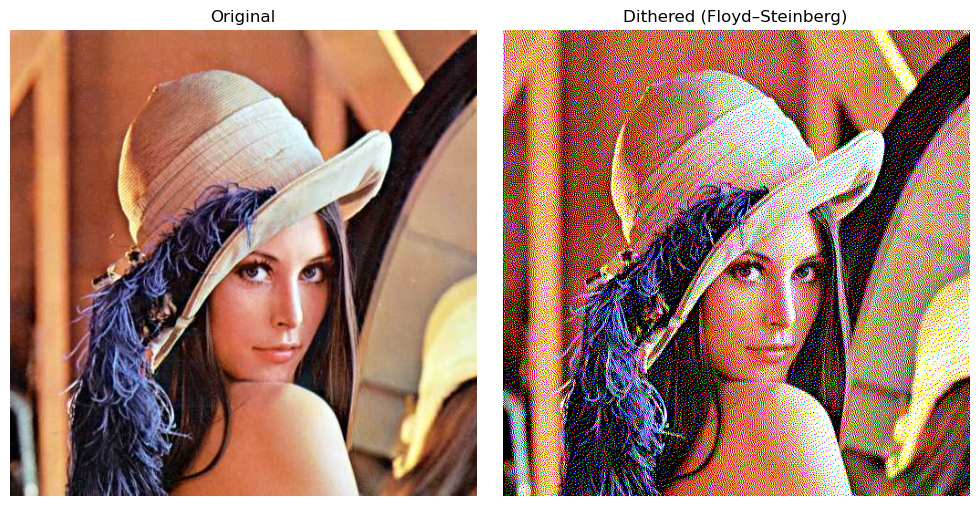

In [15]:
img_lena = cv2.imread('../assets/lena.jpg')

if img_lena is None:
    raise Exception('Image is not found!')

def floyd_steinberg_dithering(
    img: np.ndarray
) -> np.ndarray:
    """
    Apply Floyd-Steinberg dithering to a color image (OpenCV BGR format).
    Works on each channel independently.
    """
    arr = img.astype(np.float32)
    h, w, c = arr.shape

    for y in range(h):
        for x in range(w):
            old_pixel = arr[y, x].copy()
            new_pixel = np.where(old_pixel < 128, 0, 255)
            arr[y, x] = new_pixel
            quant_error = old_pixel - new_pixel

            # Spread the error (per channel)
            if x + 1 < w:
                arr[y, x+1] += quant_error * 7/16
            if y + 1 < h and x - 1 >= 0:
                arr[y+1, x-1] += quant_error * 3/16
            if y + 1 < h:
                arr[y+1, x] += quant_error * 5/16
            if y + 1 < h and x + 1 < w:
                arr[y+1, x+1] += quant_error * 1/16

    return np.clip(arr, 0, 255).astype(np.uint8)


dithered = floyd_steinberg_dithering(img_lena)

img_lena_rgb = cv2.cvtColor(img_lena, cv2.COLOR_BGR2RGB)
dithered_rgb = cv2.cvtColor(dithered, cv2.COLOR_BGR2RGB)

# Show results with matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img_lena_rgb, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Dithered (Floyd–Steinberg)")
plt.imshow(dithered_rgb, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Grayscale Conversion, Histogram Equalization, and Floyd-Steinberg Dithering on lena_lc.jpg

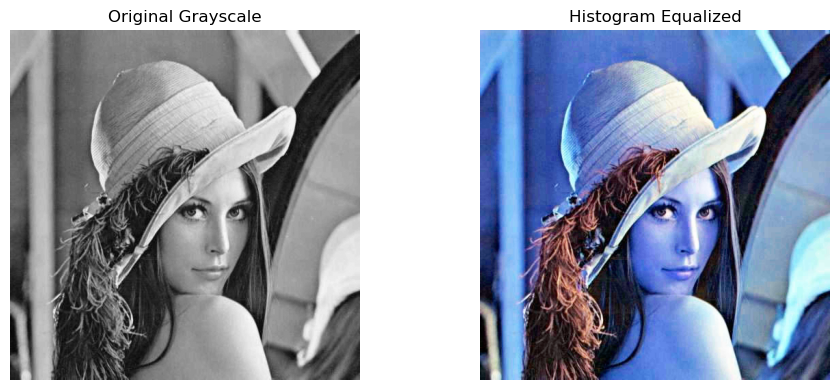

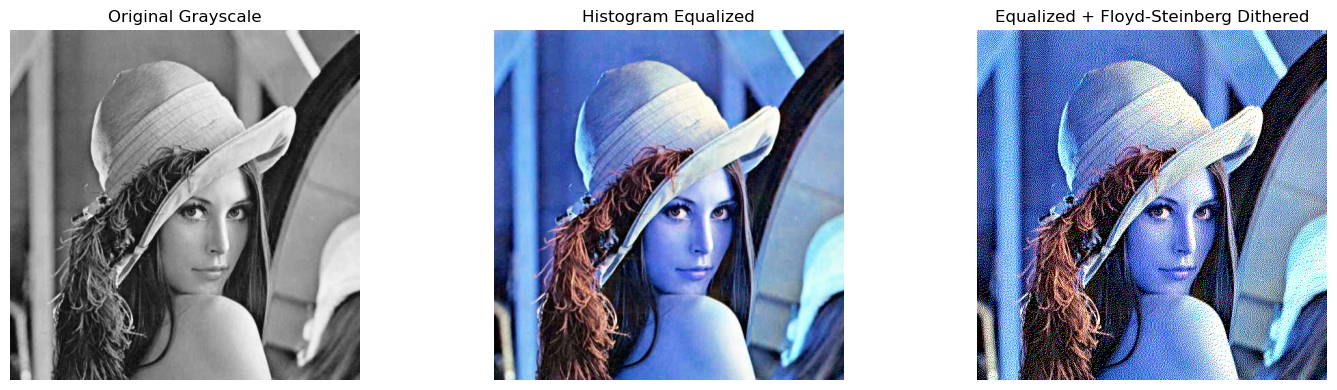

In [ ]:
img_lena_lc_gray = cv2.imread('../assets/lena-lc.jpg', cv2.IMREAD_GRAYSCALE)

if img_lena_lc_gray is None:
    raise Exception('Image is not found!')

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Grayscale")
plt.imshow(img_lena_lc_gray, cmap='gray')
plt.axis("off")

# Display the equalized image
plt.subplot(1,2,2)
plt.title("Histogram Equalized")
plt.imshow(equalized_img, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

# Apply dithering to the equalized image
img_after_dithering = floyd_steinberg_dithering(equalized_img)

# Show all three stages: Original -> Equalized -> Dithered
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.title("Original Grayscale")
plt.imshow(img_lena_lc_gray, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Histogram Equalized")
plt.imshow(equalized_img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Equalized + Floyd-Steinberg Dithered")
plt.imshow(img_after_dithering, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()